In [11]:
#display an image

import cv2
import numpy

img = cv2.imread('lena.png')

print(str(type(img)))
cv2.imshow('Color', img)
cv2.waitKey()
cv2.destroyAllWindows()

<class 'numpy.ndarray'>


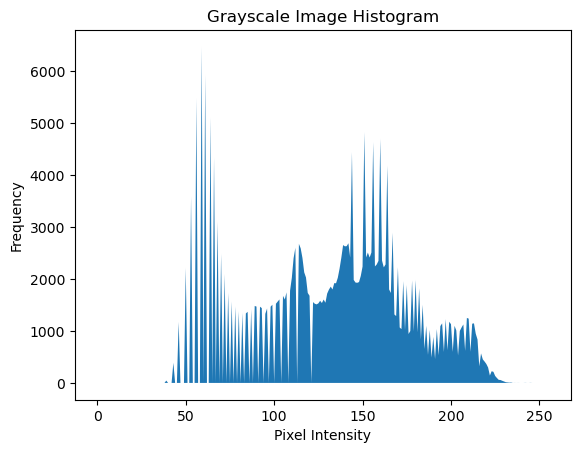

In [3]:
import cv2
import matplotlib.pyplot as plt

# Read the image in grayscale
img = cv2.imread('lena.png', cv2.IMREAD_GRAYSCALE)

# Calculate the histogram with OpenCV
# The first argument is a list of images; we only have one (img)
# The second argument is the list of channels, here [0] since it's a single-channel (grayscale) image
# The third argument (None) would be a mask if you only wanted a certain region of the image
# The fourth argument ([256]) is the number of bins
# The fifth argument ([0, 256]) is the range of pixel intensity values
hist = cv2.calcHist([img], [0], None, [256], [0, 256])
#hist, bins = np.histogram(img, 256, [0, 256])
#print(hist)

# Plot the histogram using matplotlib
plt.fill(hist)
#plt.plot(hist)
plt.title("Grayscale Image Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()


<class 'numpy.uint8'>


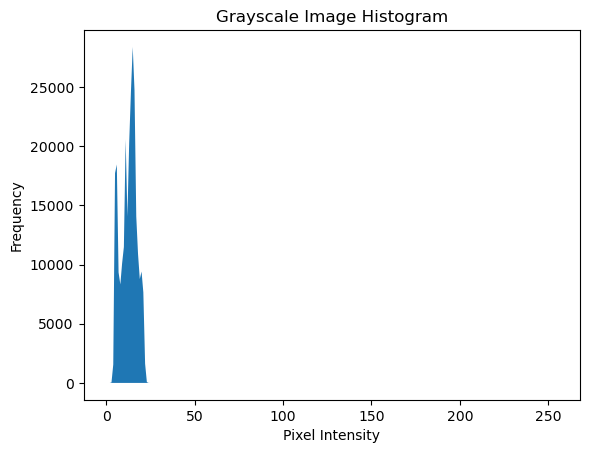

In [30]:
"""
Created on Tue Sep 10 22:18:29 2019

@author: CV
"""

#access an image pixel

import cv2
import numpy
import matplotlib.pyplot as plt

gray_img = cv2.imread('lena.png',cv2.IMREAD_GRAYSCALE)
print(type(gray_img[0,0]))
height, width = gray_img.shape
cv2.imshow('original', gray_img)

#gray_img[:,:]=gray_img[:,:]/2
for y in range(0,height):
    for x in range(0,width):
        gray_img[y,x]=gray_img[y,x]/10

hist = cv2.calcHist([gray_img], [0], None, [256], [0, 256])
plt.fill(hist)
plt.title("Grayscale Image Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

cv2.imshow('reduced', gray_img)
cv2.waitKey()
cv2.destroyAllWindows()

<class 'numpy.uint8'>


True

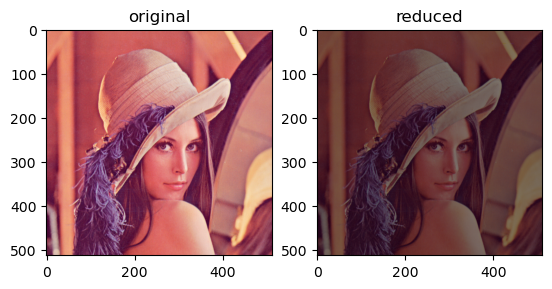

In [34]:
# %load opencv_show_image.py
"""
Created on Tue Sep 10 22:18:29 2019

@author: CV
"""

#access a color image pixel

import cv2
import numpy
import matplotlib.pyplot as plt

img = cv2.imread('lena.png')
print(type(img[0,0,0]))
height, width, channel = img.shape

#re-order color channels
#img2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
b,g,r = cv2.split(img)  
img2 = cv2.merge([r,g,b])  

plt.subplot(1,2,1)
plt.title('original')
plt.imshow(img2)

#img2[:,:,:]=img2[:,:,:]/2
for y in range(0,height):
    for x in range(0,width):
        img2[y,x,:]=img2[y,x,:]/2
        #img2[y,x,0]=img2[y,x,0]/2
        #img2[y,x,1]=img2[y,x,1]/2
        #img2[y,x,2]=img2[y,x,2]/2
        
plt.subplot(1,2,2)
plt.title('reduced')
plt.imshow(img2)

#need to re-order color channels again!
cv2.imwrite('test.png', img2)

###### %%writefile test
## Practice
1. Read an image from file
2. Show the original image using matplotlib.pyplot!
3. For each pixel, compute its <i>distance</i> from image center
4. For each pixel, set <i>weight</i> = (360. - <i>distance</i>) / 360.
5. For each pixel, multiply its brightness by the <i>weight</i> to produce vignetting effect
4. Show the vignetting image using matplotlib.pyplot
5. Write the image to file
6. Upload your image file
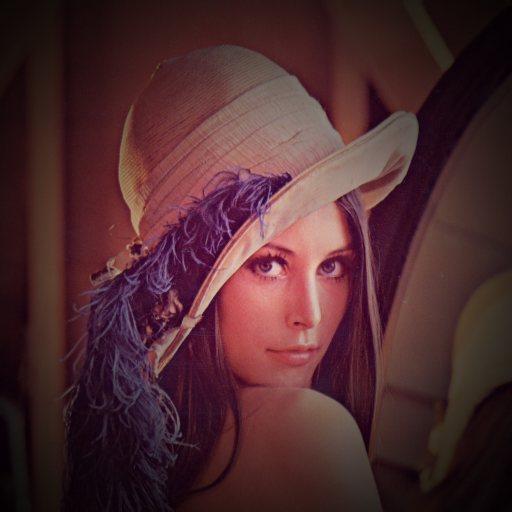

<class 'numpy.uint8'>
<class 'tuple'>
(256.0, 256.0)


True

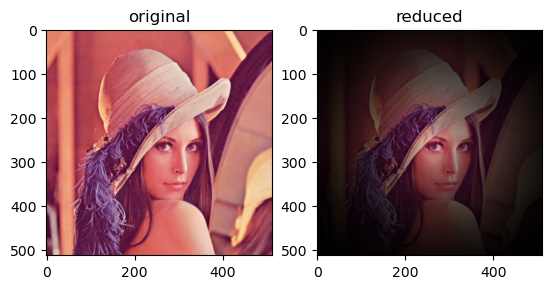

In [11]:
# %load opencv_show_image.py
"""
Created on Tue Sep 10 22:18:29 2019

@author: CV
"""

#access a color image pixel

import cv2
import numpy
import math
import matplotlib.pyplot as plt

img = cv2.imread('lena.png')
print(type(img[0,0,0]))
height, width, channel = img.shape

#re-order color channels
#img2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
b,g,r = cv2.split(img)  
img2 = cv2.merge([r,g,b])  

center = (height/2, width/2)

#print(height, width)
print(type(center))
print(center)

plt.subplot(1,2,1)
plt.title('original')
plt.imshow(img2)

#img2[:,:,:]=img2[:,:,:]/2
for y in range(0,height):
    for x in range(0,width):
        distance = math.dist(center, (y,x))
        weight = (365-distance)/365
        #print(f"The distance of {(y,x)} is: {distance}")
        img2[y,x,:]=img2[y,x,:]*(weight**2)
        #img2[y,x,0]=img2[y,x,0]/2
        #img2[y,x,1]=img2[y,x,1]/2
        #img2[y,x,2]=img2[y,x,2]/2
        
plt.subplot(1,2,2)
plt.title('reduced')
plt.imshow(img2)

#need to re-order color channels again!
img2 = cv2.cvtColor(img2, cv2.COLOR_RGB2BGR)
cv2.imwrite('611421201_0924.png', img2)